# Retail Demand Forecasting

## Project objective:

This project investigates whether recent sales history can be used to forecast weekly product demand. Using transactions from a UK online retailer, the objective is to predict demand one week ahead for frequently sold products.

A simple baseline demand prediction is compared with linear regression, Ridge regression, and Random Forest models. Validation RMSE is used for model and hyperparameter selection. Final performance is evaluated on the held-out test period using MAE and RMSE.

In [1]:
# Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

In [2]:
# Dataset

df = pd.read_excel("../data/Online Retail.xlsx")

In [3]:
# Choice of dataset

# Odd looking stock codes

non_product_codes = {
    "POST", "DOT", "M", "m", "AMAZONFEE", "S", "B"
}

df_clean = df[
    (df["Quantity"] > 0)
    & (df["UnitPrice"] > 0) 
    & ~(df["StockCode"].astype(str).isin(non_product_codes))
    & (df["Country"] == "United Kingdom")
].copy()

## Motivations for the choice of dataset:

- We choose to consider the following cleaned dataset. Keep positive values (unit prices + Quantity) — this excludes cancellations + zero-price exceptional transactions.

- Removing odd looking stock codes.

- Keeping UK transactions only.

In [4]:
# Assign each transaction to a week

df_clean["Week"] = df_clean["InvoiceDate"].dt.to_period("W")

In [5]:
# The first and last weeks and last weeks are incomplete

print(df_clean["InvoiceDate"].min(), df_clean["Week"].min())
print(df_clean["InvoiceDate"].max(), df_clean["Week"].max())

2010-12-01 08:26:00 2010-11-29/2010-12-05
2011-12-09 12:49:00 2011-12-05/2011-12-11


In [6]:
# Remove the first and last incomplete calendar weeks

first_week = df_clean["Week"].min()
last_week = df_clean["Week"].max()

df_clean = df_clean.loc[(df_clean["Week"] != first_week)
                        &(df_clean["Week"] != last_week)].copy()

## Forecasting setup:

Transactions are aggregated into weekly demand for each product. Products are selected using the training period only and must have sales in at least 28 of the 34 training weeks. This focuses the analysis on products with sufficiently regular demand while avoiding information leakage from the validation and test periods.

The data is divided chronologically into 34 training weeks, 9 validation weeks, and 9 test weeks. Each prediction uses demand from the preceding four weeks as features.

This is a one-week-ahead forecasting setup: when predicting each week, actual demand from previous weeks is assumed to be available.

In [7]:
# Define the full calendar weeks table + training / validation / test periods

complete_weeks = pd.period_range(
    start=first_week + 1,
    end=last_week - 1,
    freq="W"
)

train_weeks = complete_weeks[:34]
val_weeks = complete_weeks[34:43]
test_weeks = complete_weeks[43:]

In [8]:
# Construction of the weekly demand tables for all the transactions + training period 

weekly_demand = (
    df_clean
    .groupby(["StockCode", "Week"])["Quantity"]
    .sum()
    .reset_index()
    .sort_values(["StockCode", "Week"])
    .reset_index(drop=True).copy()
)

weekly_demand_training = (df_clean.loc[df_clean["Week"].isin(train_weeks)]
    .groupby(["StockCode", "Week"])["Quantity"]
    .sum()
    .reset_index()
    .sort_values(["StockCode", "Week"])
    .reset_index(drop=True).copy())

In [9]:
## Goal

# — Selection of the product universe: products which appear sufficiently often.
# — We will only work on this product selection for our forecasting problem (also for validation and tests)

# Defining the tables of active weeks (= number of of sales per couple (product, week)

active_training_weeks = (
    weekly_demand_training
    .groupby("StockCode")
    .size()
    .reset_index(name="active_weeks").copy()
)

# Product universe

eligible_products = active_training_weeks.loc[
    active_training_weeks["active_weeks"] >= 28,
    "StockCode"]

# Weekly table restricted to the product universe

weekly_demand_selected = weekly_demand.loc[weekly_demand["StockCode"].isin(eligible_products)].reset_index(drop=True)

In [10]:
# Two independent tables with stock codes and weeks for all the calendar year

products_df = pd.DataFrame({"StockCode": eligible_products})

weeks_df = pd.DataFrame({"Week": complete_weeks})

# and their 'cross-product'
product_week_grid = products_df.merge(weeks_df, how="cross")

In [11]:
# Weekly panel of weekly transactions for the selected products for the complete calendar year (52 weeks)

weekly_panel = (
    product_week_grid
    .merge(
        weekly_demand_selected,
        on=["StockCode", "Week"],
        how="left",
        validate="one_to_one"
    )
    .sort_values(["StockCode", "Week"])
    .reset_index(drop=True)
)

In [12]:
## Sanity checks: 

# We've added 3674 (= 43628 - 39954) rows. These correspond to eligible product-week combinations with no recorded transactions

print("Eligible products:", len(eligible_products))
print("Observed selected product-weeks:", weekly_demand_selected.shape)
print("Full panel expected:", len(eligible_products) * len(complete_weeks))
print("Full panel actual:", weekly_panel.shape)
print(weekly_panel["Quantity"].isna().sum())

Eligible products: 839
Observed selected product-weeks: (39954, 3)
Full panel expected: 43628
Full panel actual: (43628, 3)
3674


In [13]:
# replacing NaNs by 0s 

weekly_panel["Quantity"] = weekly_panel["Quantity"].fillna(0)

In [14]:
# Definition of lag features 

weekly_panel["lag_1"] = (
    weekly_panel
    .groupby("StockCode")["Quantity"]
    .shift(1)
)

weekly_panel["lag_2"] = (
    weekly_panel
    .groupby("StockCode")["Quantity"]
    .shift(2)
)

weekly_panel["lag_3"] = (
    weekly_panel
    .groupby("StockCode")["Quantity"]
    .shift(3)
)

weekly_panel["lag_4"] = (
    weekly_panel
    .groupby("StockCode")["Quantity"]
    .shift(4)
)

In [15]:
# Removing rows corresponding to NaNs from the weekly panel

weekly_panel_lag = weekly_panel.loc[
    weekly_panel["lag_4"].notna()
].reset_index(drop=True).copy()

In [16]:
# Definition of the different datasets for the training, validation and test periods, respectively.

train_data = weekly_panel_lag.loc[
    weekly_panel_lag["Week"].isin(train_weeks)
].copy()

val_data = weekly_panel_lag.loc[
    weekly_panel_lag["Week"].isin(val_weeks)
].copy()

test_data = weekly_panel_lag.loc[
    weekly_panel_lag["Week"].isin(test_weeks)
].copy()

In [17]:
# Definition of inputs and outputs for training / val / test periods

features = ["lag_1", "lag_2", "lag_3", "lag_4"]

X_train = train_data[features]
y_train = train_data["Quantity"]

X_val = val_data[features]
y_val = val_data["Quantity"]

X_test = test_data[features]
y_test = test_data["Quantity"]

In [18]:
# Baseline predictor — we will compare the performance of our models to the below.

val_pred_persistence = X_val["lag_1"]

In [19]:
# We compute the MAE and RMSE on the validation data (since we want to compare it to the corresponding
# training quantities)

mae_persistence = mean_absolute_error(
    y_val,
    val_pred_persistence
)

rmse_persistence = np.sqrt(
    mean_squared_error(y_val, val_pred_persistence)
)

print("Persistence MAE:", mae_persistence)
print("Persistence RMSE:", rmse_persistence)

Persistence MAE: 48.32949278241293
Persistence RMSE: 140.5081239983952


In [20]:
# Linear regression / Ordinary Least Squares

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

val_pred_linear = linear_model.predict(X_val)

# Compute the mae and rmse errors on the validation sets 

rmse_linear = np.sqrt(
    mean_squared_error(y_val, val_pred_linear)
)

mae_linear = mean_absolute_error(
    y_val, val_pred_linear
)

print("Linear regression MAE:", mae_linear)
print("Linear regression RMSE:", rmse_linear)

Linear regression MAE: 42.10171646658687
Linear regression RMSE: 106.37888118656821


In [21]:
# Ridge regression

# The set of hyperparameters for the Ridge regression

alphas = np.logspace(-4, 4, 17)

# Using validation RMSE, with standardized lag features: we train Ridge using standardized versions of lag_1–lag_4,
# and choose alpha according to RMSE on the validation set

ridge_results = []

for alpha in alphas:

    ridge_model = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=alpha))
    ])

    ridge_model.fit(X_train, y_train)

    val_pred_ridge = ridge_model.predict(X_val)

    rmse = np.sqrt(
        mean_squared_error(y_val, val_pred_ridge)
    )

    ridge_results.append((alpha, rmse))

ridge_results = pd.DataFrame(
    ridge_results,
    columns=["alpha", "validation_rmse"]
)

print(ridge_results)

           alpha  validation_rmse
0       0.000100       106.378881
1       0.000316       106.378881
2       0.001000       106.378881
3       0.003162       106.378881
4       0.010000       106.378881
5       0.031623       106.378881
6       0.100000       106.378879
7       0.316228       106.378875
8       1.000000       106.378861
9       3.162278       106.378818
10     10.000000       106.378682
11     31.622777       106.378259
12    100.000000       106.376985
13    316.227766       106.373598
14   1000.000000       106.369040
15   3162.277660       106.408821
16  10000.000000       106.907716


In [22]:
# Tuning in the ridge hyperparameter

best_row = ridge_results.loc[
    ridge_results["validation_rmse"].idxmin()
]

print(best_row)

## Interpretation 

# Ridge regularization produced only a marginal validation improvement over OLS, 
#suggesting that multicollinearity among the lag features was not a major source of predictive instability in this setup.

# The correlation among the lag features does not seem to create enough instability in the OLS predictor
# for Ridge regularization to materially improve validation performance.

alpha              1000.00000
validation_rmse     106.36904
Name: 14, dtype: float64


In [23]:
# Random forest model

# hyperparemeters

max_depths = [5, 10, None]
min_samples_leafs = [1, 5, 20]


# max_depth = depth of each tree
# min_sample_leafs = minimul number of observations per terminal node. Prevents tree that are too specific: create
# highly specifc region of the training data

results = []

# n_estimators = number of trees in the random forst
# max_features = number of random features considered at each split
# random_state = 42: generates a random pseudo-number making the code reproducible (returns the same results at every iter)

for max_depth in max_depths:
    for min_samples_leaf in min_samples_leafs:

        forest_model = RandomForestRegressor(
            n_estimators=200,
            max_depth=max_depth,
            min_samples_leaf=min_samples_leaf,
            max_features=2,
            random_state=42,
            n_jobs=-1
        )

        forest_model.fit(X_train, y_train)

        val_pred = forest_model.predict(X_val)

        val_rmse = mean_squared_error(
            y_val,
            val_pred
        ) ** 0.5

        results.append({
            "max_depth": max_depth,
            "min_samples_leaf": min_samples_leaf,
            "validation_rmse": val_rmse
        })


forest_results = pd.DataFrame(results)

In [24]:
# max_depth, min_samples_leaf = 5, 20


forest_results

# Random Forest improves validation RMSE (= 102.143628), suggesting some nonlinear structure

,max_depth,min_samples_leaf,validation_rmse
0,5.0,1,103.272827
1,5.0,5,102.678161
2,5.0,20,102.143628
3,10.0,1,104.476014
4,10.0,5,103.609450
5,10.0,20,102.499263
6,NaN,1,106.592280
7,NaN,5,103.604084
8,NaN,20,102.403322


In [25]:
# Training + validation data

X_trainval = pd.concat([X_train, X_val])
y_trainval = pd.concat([y_train, y_val])

In [26]:
# Refitting OLS on training + validation data

linear_final = LinearRegression()
linear_final.fit(X_trainval, y_trainval)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[0.2 ,0.19,0.16,0.2 ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['lag_1','lag_2','lag_3','lag_4']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,15.62
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)


In [27]:
# Refitting ridge on training + validation data with alpha = 1000

ridge_final = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1000))
])

ridge_final.fit(X_trainval, y_trainval)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('ridge', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](4,)","['lag_1','lag_2','lag_3','lag_4']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,4
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [28]:
# Refitting random forest on training + validation data with max_depth, min_samples_leaf = 5, 20

forest_final = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    min_samples_leaf=20,
    max_features=2,
    random_state=42,
    n_jobs=-1
)

forest_final.fit(X_trainval, y_trainval)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",20
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",2
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_l

In [29]:
# Predictions on the test data for the various models

test_pred_persistence = X_test["lag_1"]
test_pred_linear = linear_final.predict(X_test)
test_pred_ridge = ridge_final.predict(X_test)
test_pred_forest = forest_final.predict(X_test)

In [30]:
# Table with RMSE and MAE prediction results for different models

test_results = pd.DataFrame({
    "model": ["Persistence", "OLS", "Ridge", "Random Forest"],
    "RMSE": [
        mean_squared_error(y_test, test_pred_persistence) ** 0.5,
        mean_squared_error(y_test, test_pred_linear) ** 0.5,
        mean_squared_error(y_test, test_pred_ridge) ** 0.5,
        mean_squared_error(y_test, test_pred_forest) ** 0.5
    ],
    "MAE": [
        mean_absolute_error(y_test, test_pred_persistence),
        mean_absolute_error(y_test, test_pred_linear),
        mean_absolute_error(y_test, test_pred_ridge),
        mean_absolute_error(y_test, test_pred_forest)
    ]
})

test_results

,model,RMSE,MAE
0,Persistence,159.401050,51.860019
1,OLS,132.323747,46.880964
2,Ridge,132.521036,46.987125
3,Random Forest,135.674436,45.216895


## Interpretation:

- All learned models substantially outperform persistence.
- OLS achieves the best RMSE. Random Forest achieves the best MAE. The discrepancy suggests different behaviour in the tails.
- OLS and Ridge perform almost identically. Ridge therefore provides little practical benefit here.
- Random Forest improves validation RMSE, but does not seem to improve on test RMSE.

In [31]:
# Diagnostics table on test data. Prediction + relative + absolute of different trained models on test data 

diagnostics = test_data[["StockCode", "Week", "Quantity"]].copy()

diagnostics["pred_OLS"] = test_pred_linear
diagnostics["pred_RF"] = test_pred_forest

diagnostics["error_OLS"] = diagnostics["Quantity"] - diagnostics["pred_OLS"]
diagnostics["error_RF"] = diagnostics["Quantity"] - diagnostics["pred_RF"]

diagnostics["abs_error_OLS"] = diagnostics["error_OLS"].abs()
diagnostics["abs_error_RF"] = diagnostics["error_RF"].abs()

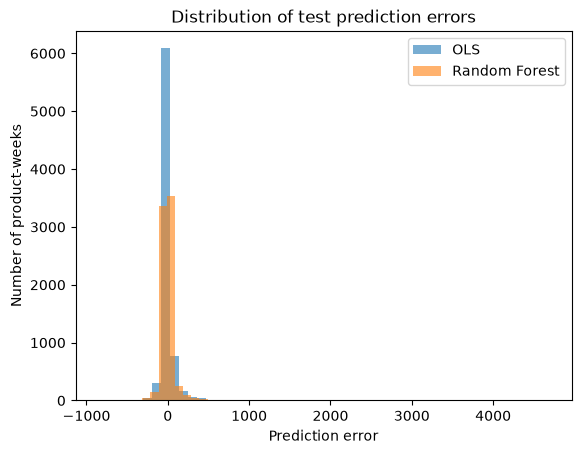

In [32]:
# Distribution of prediction errors across test product-weeks

plt.hist(diagnostics["error_OLS"], bins=50, alpha=0.6, label="OLS")
plt.hist(diagnostics["error_RF"], bins=50, alpha=0.6, label="Random Forest")

plt.xlabel("Prediction error")
plt.ylabel("Number of product-weeks")
plt.title("Distribution of test prediction errors")
plt.legend()
plt.show()

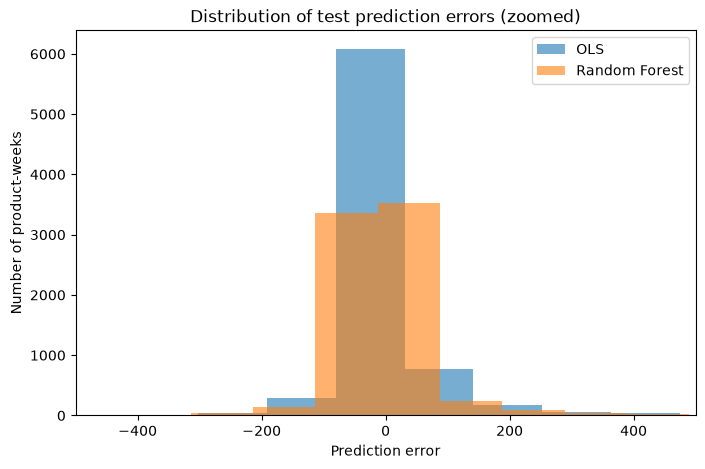

In [33]:
# Distribution of prediction errors across test product-weeks (zoomed)

plt.figure(figsize=(8, 5))

plt.hist(
    diagnostics["error_OLS"],
    bins=50,
    alpha=0.6,
    label="OLS"
)

plt.hist(
    diagnostics["error_RF"],
    bins=50,
    alpha=0.6,
    label="Random Forest"
)

plt.xlim(-500, 500)

plt.xlabel("Prediction error")
plt.ylabel("Number of product-weeks")
plt.title("Distribution of test prediction errors (zoomed)")
plt.legend()

plt.show()

## Interpretation:

- Most errors are concentrated relatively close to zero, suggesting that very large forecasting errors are uncommon. 
    
- The full distribution nevertheless has a long positive tail --> small number of weeks in which actual demand was far above the prediction.

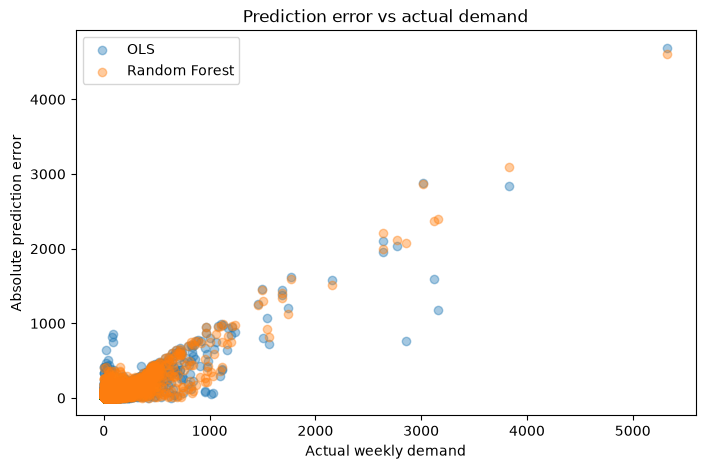

In [34]:
# Plot of the (y_i, |y_i - y_i^{pred}| for pred in {OLS, RF}

plt.figure(figsize=(8, 5))

plt.scatter(
    diagnostics["Quantity"],
    diagnostics["abs_error_OLS"],
    alpha=0.4,
    label="OLS"
)

plt.scatter(
    diagnostics["Quantity"],
    diagnostics["abs_error_RF"],
    alpha=0.4,
    label="Random Forest"
)

plt.xlabel("Actual weekly demand")
plt.ylabel("Absolute prediction error")
plt.title("Prediction error vs actual demand")
plt.legend()

plt.show()

## Interpretation:

- Prediction errors tend to become much larger for high-demand observations.

- Both OLS and Random Forest substantially underpredict some of these weeks.

- Explains why predicted RMSE >> predicted MAE: a relatively small number of very large errors receive a disproportionate weight after squaring.

In [35]:
## Goal: 

# Check the influence of low, medium and high demand on prediction performance

# Splitting diagnostics on three sub-tables for low, medium and high quantities

diagnostics["demand_bucket"] = pd.qcut(
    diagnostics["Quantity"],
    q=3,
    labels=["Low", "Medium", "High"]
)

bucket_results = []

for bucket in ["Low", "Medium", "High"]:

    bucket_data = diagnostics.loc[
        diagnostics["demand_bucket"] == bucket
    ]

    bucket_results.append({
        "demand_bucket": bucket,
        "OLS_MAE": bucket_data["abs_error_OLS"].mean(),
        "RF_MAE": bucket_data["abs_error_RF"].mean(),
        "OLS_RMSE": (bucket_data["error_OLS"] ** 2).mean() ** 0.5,
        "RF_RMSE": (bucket_data["error_RF"] ** 2).mean() ** 0.5
    })

bucket_results = pd.DataFrame(bucket_results)

bucket_results

,demand_bucket,OLS_MAE,RF_MAE,OLS_RMSE,RF_RMSE
0,Low,23.925628,20.346236,34.429654,30.046898
1,Medium,22.236320,22.067061,42.778010,37.420881
2,High,94.459302,93.316972,222.601726,230.119156


## Interpretation:

- Random Forest performs better on low and medium demand observations.

- In the high-demand bucket RF has slightly lower MAE, but OLS has lower RMSE --> RF suffers from a small number of larger misses during extreme-demand weeks.

- This indicates that Random Forest is generally more accurate for typical observations, whereas OLS handles some of the most extreme high-demand observations better.

# Overall analysis and conclusion:

- All learned models substantially outperform the persistence baseline, showing that combining several weeks of historical demand contains useful predictive information.
- OLS and Ridge perform almost identically, suggesting that Ridge regularization provides little practical benefit in this setting.
- Random Forest captures some additional nonlinear structure and achieves the lowest overall MAE, particularly improving forecasts for low- and medium-demand product-weeks.
- The main forecasting challenge is a small number of extreme demand spikes: these observations generate very large errors for both models and dominate RMSE.
- OLS handles some of the most severe high-demand misses better, giving it the best overall test RMSE, while Random Forest provides better typical absolute-error performance.
- Overall, the results do not point to one universally superior model: OLS performs better under a metric that strongly penalizes extreme errors, whereas Random Forest performs better on the typical magnitude of forecasting error.

## Limitations:

This analysis has several limitations:

- Predictions use only the previous four weeks of demand. Prices, promotions, holidays, product characteristics, and longer-term seasonal patterns are not included.
- Product-weeks without recorded transactions are treated as zero demand, although the dataset does not distinguish between no demand and unavailable stock.
- The analysis is restricted to frequently sold products from UK transactions, so the results may not generalize to less active products or other markets.
- The models are evaluated one week ahead using observed demand from preceding weeks. Performance may be weaker for forecasts made several weeks into the future without updated observations.
- A small number of extreme demand spikes generate disproportionately large errors, particularly under RMSE.